# Notebook Objectives

This notebook computes neural values for one session. For all sessions, we do the same in ```neural_value_RUN_all_sessions.py```, results shown in ```neural_value_all_sessions.ipynb```.

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)
* Change in neural value, etc

---
# Setup


In [ ]:
from neural_value_helpers import *
from popy.config import COLORS

In [ ]:
##% data loading
def load_mega_custom(monkey=None, area=None, subregion=None, downsample=True):
    # load data (meta session)
    floc = os.path.join(PATH, 'data', 'processed', 'neural_data', 'meta_rates_history')
    neural_dataset =  xr.open_dataset(floc + '/meta_rates.nc')

    if area is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.area == area)
    if subregion is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.subregion == subregion)

    if monkey is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.monkey == monkey)

    # use only time points of every .1 s
    if downsample:
        time_vector = neural_dataset.time.values
        time_vector = np.unique(np.round(time_vector, 1))  # round to 1 decimal place to avoid floating point issues
        neural_dataset = neural_dataset.sel(time=time_vector, method='nearest')

    # add coordinates (should be added during the dataset creation)
    neural_dataset = neural_dataset.assign_coords(R_1=('trial_id', [0 if hist in [0, 1, 2, 3] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_2=('trial_id', [0 if hist in [0, 1, 4, 5] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_3=('trial_id', [0 if hist in [0, 2, 4, 6] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(fb_sequence=('trial_id', neural_dataset.history_of_feedback.values))
    neural_dataset = neural_dataset.assign_coords(fb_sequence_m1=('trial_id', neural_dataset.history_of_feedback.values%4))
    neural_dataset = neural_dataset.assign_coords(time_m1=('time', neural_dataset.time.values + 7.5))

    # normalize firing rates (z-score) and remove units with low firing rates
    threshold = 1  # Hz
    units_to_remove = []
    normalized_data = np.zeros_like(neural_dataset.firing_rates.data)  # Create a copy to avoid modifying the original data
    for i, unit in enumerate(neural_dataset.unit.values):  # Loop through each neuron
        # Get all data for this neuron across trials and timepoints
        unit_data = neural_dataset.firing_rates.sel(unit=unit).values
        
        # Calculate mean and std across all values for this neuron
        mean_val = np.mean(unit_data)
        std_val = np.std(unit_data)
        
        # Z-score normalize and store in the output array
        if mean_val < threshold:
            units_to_remove.append(unit)
        elif std_val == 0:
            raise ValueError(f"Standard deviation is zero for unit {unit}. Not possible.")
        else:
            z_scored_data = (unit_data - mean_val) / std_val        
            normalized_data[:, i, :] = z_scored_data
    #neural_dataset.firing_rates.values = normalized_data
    neural_dataset['firing_rates'] = (neural_dataset.firing_rates.dims, normalized_data)

    neural_dataset = neural_dataset.sel(unit=~neural_dataset.unit.isin(units_to_remove))
    print(f"Removed {len(units_to_remove)} units with mean firing rate < {threshold} Hz")

    return neural_dataset

##% data loading
def load_mega_custom_target(monkey=None, area=None, subregion=None, downsample=True):
    # load data (meta session)
    floc = os.path.join(PATH, 'data', 'processed', 'neural_data', 'meta_rates_value_target_copy')
    neural_dataset =  xr.open_dataset(floc + '/meta_rates.nc')

    if area is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.area == area)
    if subregion is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.subregion == subregion)

    if monkey is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.monkey == monkey)

    # use only time points of every .1 s
    if downsample:
        time_vector = neural_dataset.time.values
        time_vector = np.unique(np.round(time_vector, 1))  # round to 1 decimal place to avoid floating point issues
        neural_dataset = neural_dataset.sel(time=time_vector, method='nearest')

    # one-hot target coding
    target_vector = neural_dataset.target.values.mean(axis=0)
    stay_value_vector = neural_dataset.stay_value.values.mean(axis=0)
    # remove target and stay_value columns from coords
    neural_dataset = neural_dataset.drop_vars(['target', 'stay_value'])
    # add new target and stay_value coordinates
    neural_dataset = neural_dataset.assign_coords(target=('trial_id', target_vector))
    neural_dataset = neural_dataset.assign_coords(fb_sequence=('trial_id', stay_value_vector))
    neural_dataset = neural_dataset.assign_coords(target_1=('trial_id', [1 if target_ == 1 else 0 for target_ in target_vector]))
    neural_dataset = neural_dataset.assign_coords(target_2=('trial_id', [1 if target_ == 2 else 0 for target_ in target_vector]))
    neural_dataset = neural_dataset.assign_coords(target_3=('trial_id', [1 if target_ == 3 else 0 for target_ in target_vector]))

    # normalize firing rates (z-score) and remove units with low firing rates
    threshold = 1  # Hz
    units_to_remove = []
    normalized_data = np.zeros_like(neural_dataset.firing_rates.data)  # Create a copy to avoid modifying the original data
    for i, unit in enumerate(neural_dataset.unit.values):  # Loop through each neuron
        # Get all data for this neuron across trials and timepoints
        unit_data = neural_dataset.firing_rates.sel(unit=unit).values
        
        # Calculate mean and std across all values for this neuron
        mean_val = np.mean(unit_data)
        std_val = np.std(unit_data)
        
        # Z-score normalize and store in the output array
        if mean_val < threshold:
            units_to_remove.append(unit)
        elif std_val == 0:
            raise ValueError(f"Standard deviation is zero for unit {unit}. Not possible.")
        else:
            z_scored_data = (unit_data - mean_val) / std_val        
            normalized_data[:, i, :] = z_scored_data
    #neural_dataset.firing_rates.values = normalized_data
    neural_dataset['firing_rates'] = (neural_dataset.firing_rates.dims, normalized_data)

    neural_dataset = neural_dataset.sel(unit=~neural_dataset.unit.isin(units_to_remove))
    print(f"Removed {len(units_to_remove)} units with mean firing rate < {threshold} Hz")

    return neural_dataset

In [ ]:
neural_dataset_all = load_mega_custom_target(downsample=True, monkey='ka')
target = 'R_1'  # target for the decoder, can be R_1, R_2, R_3, or switch

# create a new figure: the accuracies across areas
neural_dataset_all

1.0
Removed 118 units with mean firing rate < 1 Hz


<xarray.Dataset>
Dimensions:           (time: 151, trial_id: 144, unit: 1019)
Coordinates: (12/15)
  * time              (time) float64 -7.5 -7.4 -7.3 -7.2 ... 7.2 7.3 7.4 7.49
  * trial_id          (trial_id) int64 0 1 2 3 4 5 6 ... 138 139 140 141 142 143
  * unit              (unit) object 'ka_010720_LPFC_04_01' ... 'ka_310820_MCC...
    unit_id_original  (unit) int64 ...
    channel           (unit) int64 ...
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    ...                ...
    epoch             (time) float64 ...
    target            (unit, trial_id) float64 1.0 1.0 1.0 1.0 ... 3.0 3.0 3.0
    stay_value        (unit, trial_id) int64 ...
    target_1          (trial_id) int64 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0
    target_2          (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    target_3          (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1
Data variables:
    firing_rates      (trial_id, unit, time) float64 3.737 1.271 ... 2.013
Attributes:
    bin_size:  0.01

---
# Get the across time thing (alongside the decoding performance and projection, but in low resolution)

In [ ]:

for subregion in np.unique(neural_dataset_all.subregion.values):
    neural_dataset_subregion = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
    ## 1. plot monkey average
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset_subregion, target=target, across_time=True)

    fig, axes = plot_across_time_decodability(projected_data=data_projected, decodability_matrix=decodability_matrix, vmin=0.6, vmax=.9, cmap='Greys')
    plt.suptitle(f'both monkeys {subregion}, decoding {target}', fontsize=10, y=1.02)
    fig.savefig(f'figs/neural_value/mega_session/KA&PO_mega_session_{subregion}_across_time_decodability.svg', bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig)

    fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
    
    ax.set_title(f'both monkeys {subregion} ')
    plt.show()
    plt.close(fig)

    '''## 2. prot per monkey
    for monkey in np.unique(neural_dataset_all.monkey.values):
        neural_dataset = neural_dataset_subregion.sel(unit=neural_dataset_subregion.monkey==monkey)
        #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
        decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset, target='R_1', across_time=True)

        fig, axes = plot_across_time_decodability(projected_data=data_projected, decodability_matrix=decodability_matrix, vmin=0.1, vmax=.9)
        plt.suptitle(f'{monkey} {subregion}', fontsize=10, y=1.02)
        #fig.savefig(f'figs/neural_value/mega_session/{monkey}_mega_session_{subregion}_across_time_decodability.svg', bbox_inches='tight', transparent=True)
        plt.show()
        plt.close(fig)

        fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
        ax.set_title(f'{monkey} {subregion}')
        plt.show()
        plt.close(fig)'''


# Get projections in high resolution

In [ ]:
neural_dataset_all = load_mega_custom(downsample=False)

# create a new figure: the accuracies across areas

for subregion in np.unique(neural_dataset_all.subregion.values):
    neural_dataset_subregion = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
    ## 1. plot monkey average
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    _, data_projected = time_resolved_decoder_all_time(neural_dataset_subregion, target='R_1', across_time=False)

    fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
    ax.set_title(f'both monkeys {subregion} ')
    fig.savefig(f'figs/neural_value/mega_session/KA&PO_mega_session_{subregion}_projected_data.svg', bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig)

    ## 2. prot per monkey
    for monkey in np.unique(neural_dataset_all.monkey.values):
        neural_dataset = neural_dataset_subregion.sel(unit=neural_dataset_subregion.monkey==monkey)
        #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
        _, data_projected = time_resolved_decoder_all_time(neural_dataset, target='R_1', across_time=False)

        fig, ax = plot_projected_data(data_projected, t_interest_value=None, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
        ax.set_title(f'{monkey} {subregion}')
        fig.savefig(f'figs/neural_value/mega_session/{monkey}_mega_session_{subregion}_projected_data.svg', bbox_inches='tight', transparent=True)
        plt.show()
        plt.close(fig)


# analyse only the decoding performance (not the across time thing)

In [ ]:
neural_dataset_all = load_mega_custom(downsample=True)

# create a new figure: the accuracies across areas

decodabilities = {}
for subregion in np.unique(neural_dataset_all.subregion.values):
    neural_dataset_subregion = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
    ## 1. plot monkey average
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset_subregion, target='R_1', across_time=False)

    decodabilities[str(subregion)] = data_projected


In [ ]:
fig, ax = plt.subplots(figsize=(2.5, 2))

for subregion, data_projected in decodabilities.items():
    data = data_projected.decodability.values
    data = np.convolve(data, np.ones((50,))/50, mode='same')
    ax.plot(data_projected.time.values, data, label=subregion, color=COLORS[subregion], lw=2)


ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='Chance level')
    
plot_keypoints(ax, (-1, 0), mark_event='Fb', xlabels='events')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.5, linestyle='--', axis='x')
ax.set_xlim([-5, 5])
ax.set_ylim([0.4, 1.01])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy', fontsize=10)
ax.legend()

# save figure
plt.suptitle(f'KA & PO mega session, across subregions', fontsize=10, y=1.02)
fig.savefig(f'figs/neural_value/mega_session/KA&PO_mega_session_decodability.svg', bbox_inches='tight', transparent=True)
plt.show()


## Extract neural value

In [ ]:
data_projected

# analyse only the decoding performance (not the across time thing)

In [ ]:
neural_dataset_all = load_mega_custom_target(downsample=True, monkey='ka')
neural_dataset_all

Removed 118 units with mean firing rate < 1 Hz


<xarray.Dataset>
Dimensions:           (time: 151, trial_id: 144, unit: 1019)
Coordinates: (12/15)
  * time              (time) float64 -7.5 -7.4 -7.3 -7.2 ... 7.2 7.3 7.4 7.49
  * trial_id          (trial_id) int64 0 1 2 3 4 5 6 ... 138 139 140 141 142 143
  * unit              (unit) object 'ka_010720_LPFC_04_01' ... 'ka_310820_MCC...
    unit_id_original  (unit) int64 ...
    channel           (unit) int64 ...
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    ...                ...
    epoch             (time) float64 ...
    target            (trial_id) float64 1.0 1.0 1.0 1.0 1.0 ... 3.0 3.0 3.0 3.0
    fb_sequence       (trial_id) float64 0.0 0.0 0.0 0.0 0.0 ... 3.0 3.0 3.0 3.0
    target_1          (trial_id) int64 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0
    target_2          (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    target_3          (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1
Data variables:
    firing_rates      (trial_id, unit, time) float64 3.737 1.271 ... 2.013
Attributes:
    bin_size:  0.01

In [ ]:

# print the number of units per area and monkey
print("Number of units per area and monkey:")
for subregion in np.unique(neural_dataset_all.subregion.values):
    for monkey in np.unique(neural_dataset_all.monkey.values):
        num_units = len(neural_dataset_all.sel(unit=(neural_dataset_all.subregion == subregion) & (neural_dataset_all.monkey == monkey)).unit)
        print(f"Area: {subregion}, Monkey: {monkey}, Units: {num_units}")

# print units per monkey
print("Number of units per monkey:")
for monkey in np.unique(neural_dataset_all.monkey.values):
    num_units = len(neural_dataset_all.sel(unit=(neural_dataset_all.monkey == monkey)).unit)
    print(f"Monkey: {monkey}, Units: {num_units}")
    

neural_dataset_all


Number of units per area and monkey:
Area: MCC, Monkey: ka, Units: 507
Area: dLPFC, Monkey: ka, Units: 342
Area: vLPFC, Monkey: ka, Units: 170
Number of units per monkey:
Monkey: ka, Units: 1019


<xarray.Dataset>
Dimensions:           (time: 151, trial_id: 144, unit: 1019)
Coordinates: (12/15)
  * time              (time) float64 -7.5 -7.4 -7.3 -7.2 ... 7.2 7.3 7.4 7.49
  * trial_id          (trial_id) int64 0 1 2 3 4 5 6 ... 138 139 140 141 142 143
  * unit              (unit) object 'ka_010720_LPFC_04_01' ... 'ka_310820_MCC...
    unit_id_original  (unit) int64 ...
    channel           (unit) int64 ...
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    ...                ...
    epoch             (time) float64 ...
    target            (trial_id) float64 1.0 1.0 1.0 1.0 1.0 ... 3.0 3.0 3.0 3.0
    fb_sequence       (trial_id) float64 0.0 0.0 0.0 0.0 0.0 ... 3.0 3.0 3.0 3.0
    target_1          (trial_id) int64 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0
    target_2          (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    target_3          (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1
Data variables:
    firing_rates      (trial_id, unit, time) float64 3.737 1.271 ... 2.013
Attributes:
    bin_size:  0.01

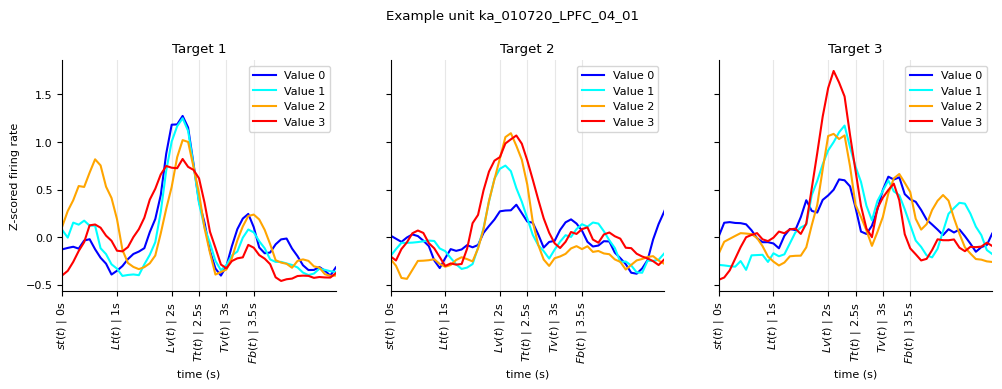

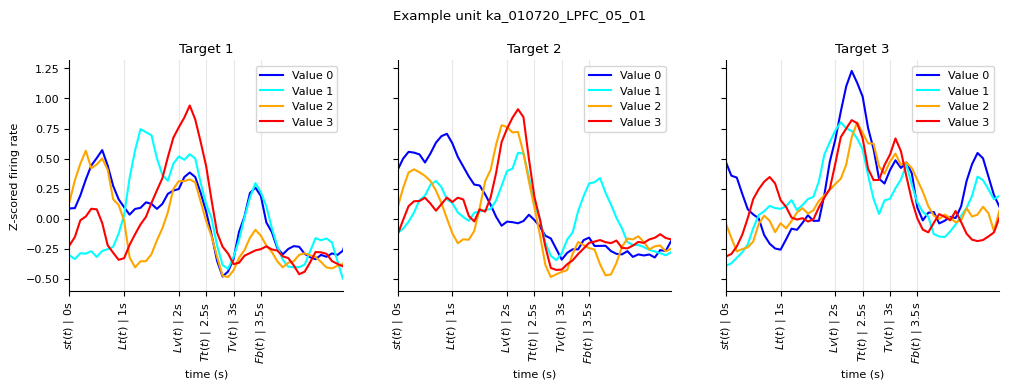

In [ ]:
# plot example unit per target and value

for i in range(2):
    unit = neural_dataset_all.unit.values[i]  # select the first unit

    t_interest = [0, 5]  # time points of interest: cue, delay, feedback
    unit_data = neural_dataset_all.sel(unit=unit)

    # gradient from blue to red, 4 levels
    colors = ['blue', 'cyan', 'orange', 'red']

    fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
    plt.suptitle(f'Example unit {unit}', y=1.05)

    for i, target in enumerate([1, 2, 3]):
        for value in [0, 1, 2, 3]:
            data_to_plot = unit_data.firing_rates.sel(trial_id=(unit_data.target == target) & (unit_data.fb_sequence == value)).mean(dim='trial_id')
            # smooth the data with a rolling window of 5 time points
            data_to_plot = data_to_plot.rolling(time=5, center=True).mean()
            axs[i].plot(unit_data.time, data_to_plot, label=f'Value {value}', color=colors[value])
        axs[i].set_title(f'Target {target}')
        axs[i].set_xlabel('Time (s)')
        if i == 0:
            axs[i].set_ylabel('Z-scored firing rate')
        axs[i].legend()
        plot_keypoints(axs[i])
        axs[i].grid(axis='x', alpha=0.3)
        axs[i].set_xlim(t_interest)
        sns.despine()

    plt.show()

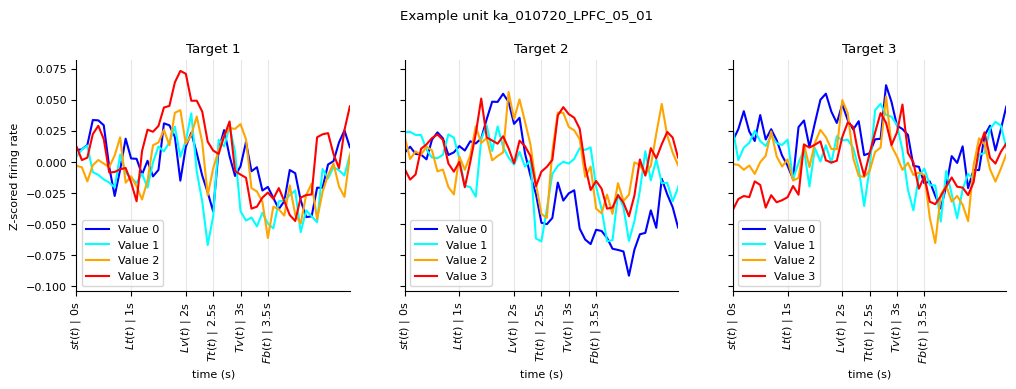

In [ ]:
# plot example unit per target and value


t_interest = [0, 5]  # time points of interest: cue, delay, feedback

# gradient from blue to red, 4 levels
colors = ['blue', 'cyan', 'orange', 'red']

fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
plt.suptitle(f'Example unit {unit}', y=1.05)

for i, target in enumerate([1, 2, 3]):
    for value in [0, 1, 2, 3]:
        data_to_plot = neural_dataset_all.firing_rates.sel(trial_id=(neural_dataset_all.target == target) & (neural_dataset_all.fb_sequence == value), unit=neural_dataset_all.subregion == 'dLPFC').mean(dim='unit').mean(dim='trial_id')
        # smooth the data with a rolling window of 5 time points
        #data_to_plot = data_to_plot.rolling(time=5, center=True).mean()
        axs[i].plot(neural_dataset_all.time, data_to_plot, label=f'Value {value}', color=colors[value])
    axs[i].set_title(f'Target {target}')
    axs[i].set_xlabel('Time (s)')
    if i == 0:
        axs[i].set_ylabel('Z-scored firing rate')
    axs[i].legend()
    plot_keypoints(axs[i])
    axs[i].grid(axis='x', alpha=0.3)
    axs[i].set_xlim(t_interest)
    sns.despine()

plt.show()

In [ ]:
# create a new figure: the accuracies across areas
target_temp = 'target_3'
decodabilities = {}
for subregion in np.unique(neural_dataset_all.subregion.values):
    neural_dataset_subregion = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
    ## 1. plot monkey average
    #results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
    decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset_subregion, target=target_temp, across_time=False)

    decodabilities[str(subregion)] = data_projected


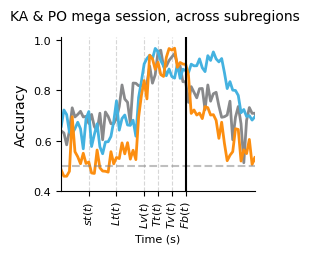

In [ ]:
fig, ax = plt.subplots(figsize=(2.5, 2))

for subregion, data_projected in decodabilities.items():
    data = data_projected.decodability.values
    #data = np.convolve(data, np.ones((50,))/50, mode='same')
    ax.plot(data_projected.time.values, data, label=subregion, color=COLORS[subregion], lw=2)


ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='Chance level')
    
plot_keypoints(ax, (-1, 0), mark_event='Fb', xlabels='events')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.5, linestyle='--', axis='x')
ax.set_xlim([-1, 6])
ax.set_ylim([0.4, 1.01])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy', fontsize=10)
#ax.legend()

# save figure
plt.suptitle(f'KA & PO mega session, across subregions', fontsize=10, y=1.02)
fig.savefig(f'figs/neural_value/mega_session/KA&PO_mega_session_decodability.svg', bbox_inches='tight', transparent=True)
plt.show()


## project to subspace DVS

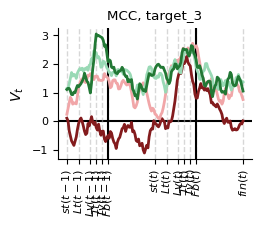

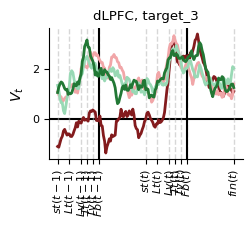

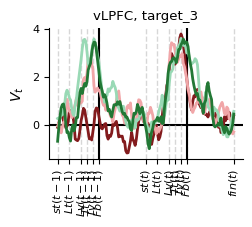

In [ ]:
for subregion, data in decodabilities.items():    
    data_projected_temp = data.sel(trial_id=data[target_temp]==1)
    fig, ax = plot_projected_data(data_projected_temp, t_interest_value=None, n_extra_trials=(-1, 0), paper_format=True)#, xlim=[1, 6])
    # title
    ax.set_title(f'{subregion}, {target_temp}')